# Sistemas Inteligentes I
## Búsqueda no informada: BFS y DFS

**Autor:** Jairo I. Vélez B.

---

### Propósito de la práctica

En este notebook estudiaremos cómo resolver problemas mediante **búsqueda no informada**, es decir, estrategias que exploran el espacio de estados **sin disponer de una estimación sobre qué tan cerca se encuentra cada estado del objetivo**.

Al finalizar la práctica, el estudiante estará en capacidad de:

- Representar un problema mediante un **espacio de estados**.
- Implementar **Búsqueda en Anchura (BFS)**.
- Implementar **Búsqueda en Profundidad (DFS)**.
- Comparar el comportamiento de BFS y DFS.
- Aplicar estos algoritmos a problemas concretos.
- Analizar ventajas, limitaciones y costo de exploración.

## 1. Idea general: buscar sin información adicional

Un problema de búsqueda puede describirse mediante:

- **Estado inicial:** punto desde el cual comienza la búsqueda.
- **Estados:** configuraciones posibles del problema.
- **Acciones u operadores:** transformaciones permitidas entre estados.
- **Función sucesor:** determina qué estados pueden alcanzarse desde un estado dado.
- **Prueba de objetivo:** determina si se alcanzó la solución.

En la búsqueda no informada, el algoritmo **no conoce qué estado parece más prometedor**.  
Solo utiliza la estructura del espacio de búsqueda.

Dos estrategias fundamentales son:

- **BFS (Breadth-First Search):** explora por niveles.
- **DFS (Depth-First Search):** profundiza por una rama antes de retroceder.

## 2. Librerías utilizadas

Se utilizarán únicamente estructuras básicas de Python y matplotlib para algunas visualizaciones.

In [32]:
from collections import deque
import matplotlib.pyplot as plt

print("Entorno listo.")

Entorno listo.


# 3. Primer espacio de estados: un grafo

Consideremos el siguiente grafo no ponderado:

- **Estado:** un nodo.
- **Estado inicial:** `A`.
- **Acciones:** desplazarse hacia un nodo adyacente.
- **Objetivo inicial de la demostración:** observar el orden de exploración.

La representación mediante un diccionario de listas de adyacencia es:

In [33]:
grafo = {
    "A": ["B", "F"],
    "B": ["A", "C", "E"],
    "C": ["B", "D", "E"],
    "D": ["C", "E", "F"],
    "E": ["B", "C", "D"],
    "F": ["A", "D"],
}

grafo

{'A': ['B', 'F'],
 'B': ['A', 'C', 'E'],
 'C': ['B', 'D', 'E'],
 'D': ['C', 'E', 'F'],
 'E': ['B', 'C', 'D'],
 'F': ['A', 'D']}

## 4. Búsqueda en Anchura — BFS

BFS utiliza una **cola FIFO** (*First In, First Out*).

La idea es simple:

1. Insertar el estado inicial en la cola.
2. Extraer el primer estado de la cola.
3. Encontrar sus sucesores no visitados.
4. Insertarlos al final de la cola.
5. Repetir hasta terminar o encontrar el objetivo.

En grafos no ponderados, BFS puede encontrar un camino con el **menor número de aristas** desde el origen hasta el objetivo.

In [34]:
def bfs(grafo, inicio):
    visitados = {inicio}
    cola = deque([inicio])
    recorrido = []

    while cola:
        nodo = cola.popleft()
        recorrido.append(nodo)

        for vecino in grafo[nodo]:
            if vecino not in visitados:
                visitados.add(vecino)
                cola.append(vecino)

    return recorrido


recorrido_bfs = bfs(grafo, "A")
print("Recorrido BFS:", recorrido_bfs)

Recorrido BFS: ['A', 'B', 'F', 'C', 'E', 'D']


### 4.1 BFS paso a paso

Para comprender el algoritmo conviene observar cómo cambian la **frontera** y el conjunto de **visitados**.

In [35]:
def bfs_debug(grafo, inicio):
    visitados = {inicio}
    cola = deque([inicio])
    paso = 1

    while cola:
        print(f"\nPaso {paso}")
        print("Cola antes de expandir:", list(cola))
        print("Visitados:", sorted(visitados))

        nodo = cola.popleft()
        print("Nodo expandido:", nodo)

        for vecino in grafo[nodo]:
            if vecino not in visitados:
                visitados.add(vecino)
                cola.append(vecino)

        print("Cola después de expandir:", list(cola))
        paso += 1


bfs_debug(grafo, "A")


Paso 1
Cola antes de expandir: ['A']
Visitados: ['A']
Nodo expandido: A
Cola después de expandir: ['B', 'F']

Paso 2
Cola antes de expandir: ['B', 'F']
Visitados: ['A', 'B', 'F']
Nodo expandido: B
Cola después de expandir: ['F', 'C', 'E']

Paso 3
Cola antes de expandir: ['F', 'C', 'E']
Visitados: ['A', 'B', 'C', 'E', 'F']
Nodo expandido: F
Cola después de expandir: ['C', 'E', 'D']

Paso 4
Cola antes de expandir: ['C', 'E', 'D']
Visitados: ['A', 'B', 'C', 'D', 'E', 'F']
Nodo expandido: C
Cola después de expandir: ['E', 'D']

Paso 5
Cola antes de expandir: ['E', 'D']
Visitados: ['A', 'B', 'C', 'D', 'E', 'F']
Nodo expandido: E
Cola después de expandir: ['D']

Paso 6
Cola antes de expandir: ['D']
Visitados: ['A', 'B', 'C', 'D', 'E', 'F']
Nodo expandido: D
Cola después de expandir: []


# 5. Búsqueda en Profundidad — DFS

DFS utiliza una **pila LIFO** (*Last In, First Out*).

Su comportamiento es diferente:

1. Inserta el estado inicial en la pila.
2. Extrae el estado ubicado en la parte superior.
3. Agrega sus sucesores no visitados.
4. Continúa profundizando por una rama.
5. Cuando no puede avanzar, retrocede implícitamente mediante la pila.

> El orden en el que se generan los sucesores puede cambiar el recorrido obtenido.

In [36]:
def dfs(grafo, inicio):
    visitados = {inicio}
    pila = [inicio]
    recorrido = []

    while pila:
        nodo = pila.pop()
        recorrido.append(nodo)

        for vecino in (grafo[nodo]):
            if vecino not in visitados:
                visitados.add(vecino)
                pila.append(vecino)

    return recorrido


recorrido_dfs = dfs(grafo, "A")
print("Recorrido DFS:", recorrido_dfs)

Recorrido DFS: ['A', 'F', 'D', 'E', 'C', 'B']


### 5.1 DFS paso a paso

In [37]:
def dfs_debug(grafo, inicio):
    visitados = {inicio}
    pila = [inicio]
    paso = 1

    while pila:
        print(f"\nPaso {paso}")
        print("Pila antes de expandir:", pila)
        print("Visitados:", sorted(visitados))

        nodo = pila.pop()
        print("Nodo expandido:", nodo)

        for vecino in (grafo[nodo]):
            if vecino not in visitados:
                visitados.add(vecino)
                pila.append(vecino)

        print("Pila después de expandir:", pila)
        paso += 1


dfs_debug(grafo, "A")


Paso 1
Pila antes de expandir: ['A']
Visitados: ['A']
Nodo expandido: A
Pila después de expandir: ['B', 'F']

Paso 2
Pila antes de expandir: ['B', 'F']
Visitados: ['A', 'B', 'F']
Nodo expandido: F
Pila después de expandir: ['B', 'D']

Paso 3
Pila antes de expandir: ['B', 'D']
Visitados: ['A', 'B', 'D', 'F']
Nodo expandido: D
Pila después de expandir: ['B', 'C', 'E']

Paso 4
Pila antes de expandir: ['B', 'C', 'E']
Visitados: ['A', 'B', 'C', 'D', 'E', 'F']
Nodo expandido: E
Pila después de expandir: ['B', 'C']

Paso 5
Pila antes de expandir: ['B', 'C']
Visitados: ['A', 'B', 'C', 'D', 'E', 'F']
Nodo expandido: C
Pila después de expandir: ['B']

Paso 6
Pila antes de expandir: ['B']
Visitados: ['A', 'B', 'C', 'D', 'E', 'F']
Nodo expandido: B
Pila después de expandir: []


## 6. BFS vs. DFS

| Característica | BFS | DFS |
|---|---|---|
| Estructura principal | Cola | Pila |
| Estrategia | Explora por niveles | Profundiza por ramas |
| Camino mínimo en grafo no ponderado | Sí | No necesariamente |
| Uso de memoria | Puede ser alto | Suele ser menor |
| Riesgo principal | Explosión de memoria | Profundizar demasiado |
| ¿Usa heurística? | No | No |

### Pregunta para discutir

**¿Existe un único recorrido BFS o DFS para un grafo?**

No necesariamente. El resultado puede cambiar según el orden en que se generen o almacenen los sucesores.

# 7. Problema 1: encontrar la salida de un laberinto

Usaremos `0` para representar una celda transitable y `1` para representar una pared.

Modelado:

- **Estado:** `(fila, columna)`.
- **Estado inicial:** `(0, 0)`.
- **Objetivo:** `(4, 4)`.
- **Acciones:** arriba, abajo, izquierda y derecha.
- **Restricción:** no atravesar paredes ni salir del tablero.

In [38]:
laberinto = [
    [0, 1, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1],
    [0, 0, 0, 0, 0],
]

INICIO = (0, 0)
OBJETIVO = (4, 4)
MOVIMIENTOS = [(1, 0), (-1, 0), (0, 1), (0, -1)]

In [39]:
def sucesores_laberinto(laberinto, posicion):
    filas = len(laberinto)
    columnas = len(laberinto[0])
    f, c = posicion

    sucesores = []

    for df, dc in MOVIMIENTOS:
        nf, nc = f + df, c + dc

        if (
            0 <= nf < filas
            and 0 <= nc < columnas
            and laberinto[nf][nc] == 0
        ):
            sucesores.append((nf, nc))

    return sucesores

## 7.1 Resolver el laberinto con BFS

Además del camino, contabilizaremos cuántos estados fueron descubiertos.

In [40]:
def bfs_camino_laberinto(laberinto, inicio, objetivo):
    if laberinto[inicio[0]][inicio[1]] == 1:
        return None
    if laberinto[objetivo[0]][objetivo[1]] == 1:
        return None

    cola = deque([(inicio, [inicio])])
    visitados = {inicio}

    while cola:
        posicion, camino = cola.popleft()

        if posicion == objetivo:
            return {
                "camino": camino,
                "explorados": len(visitados),
            }

        for nuevo in sucesores_laberinto(laberinto, posicion):
            if nuevo not in visitados:
                visitados.add(nuevo)
                cola.append((nuevo, camino + [nuevo]))

    return None


resultado_bfs = bfs_camino_laberinto(laberinto, INICIO, OBJETIVO)
resultado_bfs

{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (3, 0),
  (4, 0),
  (4, 1),
  (4, 2),
  (4, 3),
  (4, 4)],
 'explorados': 16}

## 7.2 Resolver el mismo laberinto con DFS

In [41]:
def dfs_camino_laberinto(laberinto, inicio, objetivo):
    if laberinto[inicio[0]][inicio[1]] == 1:
        return None
    if laberinto[objetivo[0]][objetivo[1]] == 1:
        return None

    pila = [(inicio, [inicio])]
    visitados = {inicio}

    while pila:
        posicion, camino = pila.pop()

        if posicion == objetivo:
            return {
                "camino": camino,
                "explorados": len(visitados),
            }

        for nuevo in (sucesores_laberinto(laberinto, posicion)):
            if nuevo not in visitados:
                visitados.add(nuevo)
                pila.append((nuevo, camino + [nuevo]))

    return None


resultado_dfs = dfs_camino_laberinto(laberinto, INICIO, OBJETIVO)
resultado_dfs

{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (2, 1),
  (2, 2),
  (3, 2),
  (4, 2),
  (4, 3),
  (4, 4)],
 'explorados': 18}

## 7.3 Visualización del camino

La visualización permite comparar no solo si ambos algoritmos encuentran una solución, sino **qué tipo de camino producen**.

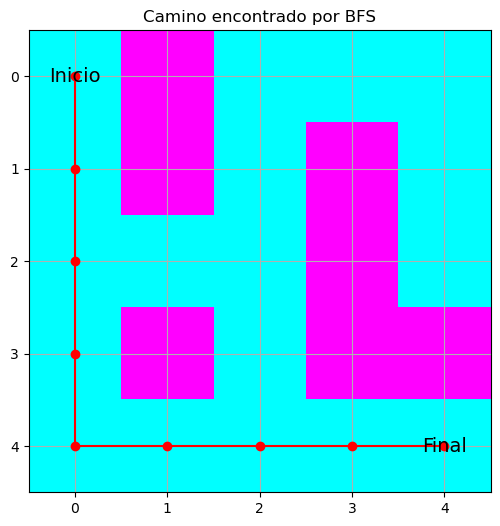

In [42]:
def mostrar_laberinto(laberinto, camino=None, inicio=None, objetivo=None, titulo="Laberinto"):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(laberinto,cmap='cool')

    if camino:
        xs = [c for f, c in camino]
        ys = [f for f, c in camino]
        ax.plot(xs, ys, c='red', marker="o")

    if inicio is not None:
        ax.text(inicio[1], inicio[0], "Inicio", ha="center", va="center", fontsize=14)
    if objetivo is not None:
        ax.text(objetivo[1], objetivo[0], "Final", ha="center", va="center", fontsize=14)

    ax.set_xticks(range(len(laberinto[0])))
    ax.set_yticks(range(len(laberinto)))
    ax.set_title(titulo)
    ax.grid(True)
    plt.show()


mostrar_laberinto(
    laberinto,
    resultado_bfs["camino"],
    INICIO,
    OBJETIVO,
    "Camino encontrado por BFS"
)

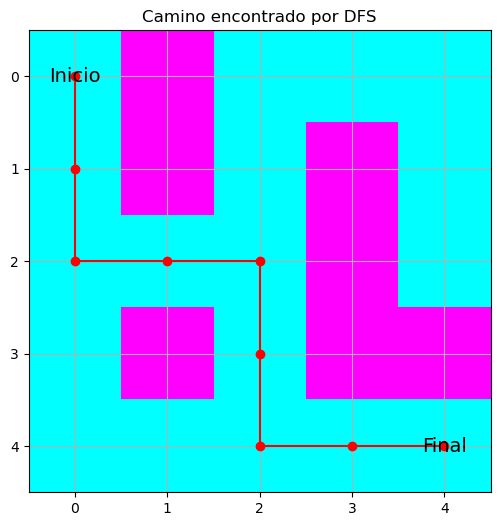

In [43]:
mostrar_laberinto(
    laberinto,
    resultado_dfs["camino"],
    INICIO,
    OBJETIVO,
    "Camino encontrado por DFS"
)

## 7.4 Comparación experimental

In [44]:
comparacion = {
    "BFS": {
        "longitud_camino": len(resultado_bfs["camino"]) - 1,
        "explorados": resultado_bfs["explorados"],
    },
    "DFS": {
        "longitud_camino": len(resultado_dfs["camino"]) - 1,
        "explorados": resultado_dfs["explorados"],
    },
}

comparacion

{'BFS': {'longitud_camino': 8, 'explorados': 16},
 'DFS': {'longitud_camino': 8, 'explorados': 18}}

### Preguntas de análisis

1. ¿Ambos algoritmos encontraron una solución?
2. ¿Los caminos tienen la misma longitud?
3. ¿Cuál exploró más estados?
4. ¿Por qué BFS puede garantizar el camino con menor número de movimientos en este problema?
5. ¿Cambiaría el resultado de DFS si modificamos el orden de `MOVIMIENTOS`?

### Respuestas

**1. ¿Ambos algoritmos encontraron una solución?**
Sí. Ambos llegan de `(0,0)` a `(4,4)`.

**2. ¿Los caminos tienen la misma longitud?**
**Sí, en este laberinto ambos caminos miden 8 movimientos.** Son rutas distintas: BFS baja por la primera columna y recorre la última fila; DFS baja hasta `(2,0)`, cruza por `(2,1)`-`(2,2)` y baja por la columna 2. El laberinto tiene dos caminos mínimos y DFS tomó el otro.
Esto **no** significa que DFS garantice el camino mínimo: aquí coincidió por la forma del laberinto (en la Parte 5, punto 2, se ve un caso donde DFS produce un camino 2,5 veces más largo).

**3. ¿Cuál exploró más estados?**
DFS: 18 estados descubiertos frente a 16 de BFS (17 frente a 15 extraídos). En este laberinto DFS llegó a descubrir las 18 celdas libres. No es una regla general (ver el punto 2 del taller).

**4. ¿Por qué BFS puede garantizar el camino con menor número de movimientos?**
Porque todas las acciones cuestan lo mismo (1) y la cola FIFO obliga a extraer todos los estados a distancia *k* antes que cualquiera a distancia *k+1*. Por tanto, el primer camino que alcanza el objetivo tiene la menor cantidad posible de movimientos.

**5. ¿Cambiaría el resultado de DFS si modificamos el orden de `MOVIMIENTOS`?**
Sí. Con una pila LIFO, el movimiento listado **al final** es el primero en explorarse, así que el orden decide la ruta y cuántos estados se descubren. Demostración con dos órdenes (el experimento completo con las 24 permutaciones está en el taller, punto 1):

# 8. Problema 2: recipientes de agua

Se dispone de:

- Un recipiente **M** con capacidad de 5 litros.
- Un recipiente **N** con capacidad de 3 litros.
- Una fuente ilimitada de agua.
- El objetivo es obtener **exactamente 4 litros**.

## Representación del estado

Un estado será una tupla:

\[
(m,n)
\]

donde:

- `m` = cantidad de agua en el recipiente M.
- `n` = cantidad de agua en el recipiente N.

Estado inicial:

\[
(0,0)
\]

### Operadores

1. Llenar M.
2. Llenar N.
3. Vaciar M.
4. Vaciar N.
5. Verter N → M.
6. Verter M → N.

In [45]:
def sucesores_recipientes(estado, M, N):
    m, n = estado

    return [
        ((M, n), "Llenar M"),
        ((m, N), "Llenar N"),
        ((0, n), "Vaciar M"),
        ((m, 0), "Vaciar N"),

        # Verter N -> M
        (
            (
                min(M, m + n),
                max(0, m + n - M)
            ),
            "Verter N → M"
        ),

        # Verter M -> N
        (
            (
                max(0, m + n - N),
                min(N, m + n)
            ),
            "Verter M → N"
        ),
    ]

In [46]:
def bfs_recipientes(M, N, objetivo):
    inicio = (0, 0)
    cola = deque([(inicio, [inicio], [])])
    visitados = {inicio}

    while cola:
        estado, camino, acciones = cola.popleft()

        if objetivo in estado:
            return {
                "estados": camino,
                "acciones": acciones,
                "explorados": len(visitados),
            }

        for nuevo_estado, accion in sucesores_recipientes(estado, M, N):
            if nuevo_estado not in visitados:
                visitados.add(nuevo_estado)
                cola.append(
                    (
                        nuevo_estado,
                        camino + [nuevo_estado],
                        acciones + [accion],
                    )
                )

    return None


solucion_recipientes = bfs_recipientes(5, 3, 4)
solucion_recipientes

{'estados': [(0, 0), (5, 0), (2, 3), (2, 0), (0, 2), (5, 2), (4, 3)],
 'acciones': ['Llenar M',
  'Verter M → N',
  'Vaciar N',
  'Verter M → N',
  'Llenar M',
  'Verter M → N'],
 'explorados': 14}

## 8.1 Mostrar la solución paso a paso

In [47]:
def mostrar_solucion_recipientes(solucion):
    if solucion is None:
        print("No se encontró solución.")
        return

    estados = solucion["estados"]
    acciones = solucion["acciones"]

    print("Estado inicial:", estados[0])

    for i, accion in enumerate(acciones, start=1):
        print(f"{i}. {accion:15s} -> {estados[i]}")

    print("\nEstados explorados:", solucion["explorados"])


mostrar_solucion_recipientes(solucion_recipientes)

Estado inicial: (0, 0)
1. Llenar M        -> (5, 0)
2. Verter M → N    -> (2, 3)
3. Vaciar N        -> (2, 0)
4. Verter M → N    -> (0, 2)
5. Llenar M        -> (5, 2)
6. Verter M → N    -> (4, 3)

Estados explorados: 14


### Preguntas de análisis

1. ¿Por qué el problema de los recipientes puede representarse como un grafo?
2. ¿Cuántos estados posibles existen como máximo?
3. ¿Qué representa una arista entre dos estados?
4. ¿Por qué BFS es una estrategia apropiada si queremos minimizar el número de operaciones?
5. ¿Qué cambiaría si cada operación tuviera un costo distinto?

### Respuestas

**1. ¿Por qué el problema de los recipientes puede representarse como un grafo?**
Porque hay un conjunto finito de configuraciones discretas (los estados `(m, n)`) y un conjunto de operadores que transforman una configuración en otra. Cada estado es un **nodo** y cada operador aplicable es una **arista** hacia el estado resultante; resolver el problema equivale a encontrar un camino desde `(0,0)` hasta un nodo con 4 L.

**2. ¿Cuántos estados posibles existen como máximo?**
Hay **24 combinaciones** en total: M toma 6 valores (0 a 5) y N toma 4 (0 a 3), es decir, (5+1)·(3+1) = 24. De ellas solo **16 son alcanzables** desde `(0,0)`. Los 8 inalcanzables son los que tienen 1 ≤ m ≤ 4 y 1 ≤ n ≤ 2. La razón es un invariante: después de cualquier operación, **al menos un recipiente queda lleno o vacío**, y esos 8 estados no cumplen esa condición (la celda de código lo comprueba).
*(La cifra "18" no es correcta: 18 no es ni el máximo ni el número de alcanzables.)*

**3. ¿Qué representa una arista entre dos estados?**
Representa la **aplicación de un operador** (llenar, vaciar o verter) que transforma un estado en otro; en este problema cada arista tiene costo 1. Las aristas son **dirigidas**: desde `(1,0)` "Llenar M" lleva a `(5,0)`, pero no existe una operación que devuelva de `(5,0)` a `(1,0)`, porque se pierde la información de cuánta agua había.

**4. ¿Por qué BFS es apropiada si queremos minimizar el número de operaciones?**
Porque cada operación cuesta 1 y BFS extrae los estados por niveles (todos los que están a *k* operaciones antes que los de *k+1*). El primer nodo objetivo que encuentra está, por tanto, a la mínima cantidad de operaciones: **6** en este caso.

**5. ¿Qué cambiaría si cada operación tuviera un costo distinto?**
BFS dejaría de ser óptimo: minimiza el **número de pasos**, no el **costo total**. Habría que usar búsqueda de costo uniforme (Dijkstra), que expande primero el estado con menor costo acumulado g(n). Ejemplo ilustrativo: si "Vaciar N" costara 10 y las demás operaciones 1:

# 9. Reto final: el 8-puzzle

El 8-puzzle consiste en un tablero de `3 × 3` con ocho fichas y una casilla vacía.

Cada configuración del tablero representa un **estado**.

El objetivo es transformar un estado inicial en un estado objetivo moviendo una ficha adyacente hacia la posición vacía.

Este problema será especialmente útil más adelante, cuando comparemos **búsqueda no informada** con **búsqueda informada y A\***.

In [48]:
estado_inicial = (
    1, 2, 3,
    4, 5, 0,
    6, 8, 7,
)

estado_objetivo = (
    1, 2, 3,
    4, 5, 6,
    7, 8, 0,
)

estado_inicial, estado_objetivo

((1, 2, 3, 4, 5, 0, 6, 8, 7), (1, 2, 3, 4, 5, 6, 7, 8, 0))

## 9.1 Generación de sucesores

El `0` representa la casilla vacía.

La siguiente función genera todos los estados alcanzables mediante **un movimiento válido**.

In [49]:
def sucesores_8_puzzle(estado):
    estado = list(estado)
    indice_cero = estado.index(0)

    fila, columna = divmod(indice_cero, 3)

    movimientos = [
        (-1, 0),
        (1, 0),
        (0, -1),
        (0, 1),
    ]

    sucesores = []

    for df, dc in movimientos:
        nf, nc = fila + df, columna + dc

        if 0 <= nf < 3 and 0 <= nc < 3:
            nuevo_indice = nf * 3 + nc
            nuevo = estado.copy()

            nuevo[indice_cero], nuevo[nuevo_indice] = (
                nuevo[nuevo_indice],
                nuevo[indice_cero],
            )

            sucesores.append(tuple(nuevo))

    return sucesores


sucesores_8_puzzle(estado_inicial)

[(1, 2, 0, 4, 5, 3, 6, 8, 7),
 (1, 2, 3, 4, 5, 7, 6, 8, 0),
 (1, 2, 3, 4, 0, 5, 6, 8, 7)]

## 9.2 Ejercicio

Implemente una función:

```python
bfs_8_puzzle(estado_inicial, estado_objetivo)
```

que devuelva:

- El camino desde el estado inicial hasta el objetivo.
- El número de movimientos.
- La cantidad de estados explorados.

### Restricciones

- Utilice BFS.
- Evite visitar dos veces el mismo estado.
- No utilice ninguna heurística.

> **Pregunta:** ¿Qué problema aparece cuando el estado inicial se encuentra muy lejos del objetivo?

In [50]:
# TODO: implemente aquí BFS para el 8-puzzle.

def bfs_8_puzzle(estado_inicial, estado_objetivo):
    """BFS para el 8-puzzle (sin heurística, sin repetir estados).

    Devuelve un diccionario con:
      - camino:      lista de estados desde el inicial hasta el objetivo (None si no hay solución)
      - movimientos: número de movimientos de la solución (None si no hay solución)
      - explorados:  estados descubiertos (len de `padre`), mismo criterio que en el laberinto
    Se guarda el padre de cada estado (en vez de copiar el camino completo en cada nodo)
    para ahorrar memoria y reconstruir el camino al final.
    """
    padre = {estado_inicial: None}
    cola = deque([estado_inicial])

    while cola:
        estado = cola.popleft()

        if estado == estado_objetivo:
            camino = []
            while estado is not None:
                camino.append(estado)
                estado = padre[estado]
            camino.reverse()
            return {
                "camino": camino,
                "movimientos": len(camino) - 1,
                "explorados": len(padre),
            }

        for nuevo in sucesores_8_puzzle(estado):
            if nuevo not in padre:
                padre[nuevo] = estado
                cola.append(nuevo)

    # Se agotó el espacio alcanzable sin encontrar el objetivo
    return {"camino": None, "movimientos": None, "explorados": len(padre)}

### 9.3 Pruebas de `bfs_8_puzzle`

Primero con el estado inicial propuesto en el notebook.

In [51]:
res = bfs_8_puzzle(estado_inicial, estado_objetivo)
print("Movimientos :", res["movimientos"])
print("Explorados  :", res["explorados"])
print("Camino      :", res["camino"])

Movimientos : None
Explorados  : 181440
Camino      : None


El estado inicial propuesto **no llega a una solución**: BFS recorre todo el espacio alcanzable y termina sin encontrar el objetivo. Se comprueba con la paridad de inversiones (en un tablero 3×3, dos estados son mutuamente alcanzables solo si tienen la misma paridad de inversiones).

In [52]:
def inversiones(estado):
    fichas = [x for x in estado if x != 0]
    return sum(
        1
        for i in range(len(fichas))
        for j in range(i + 1, len(fichas))
        if fichas[i] > fichas[j]
    )

def es_resoluble(estado, objetivo):
    return inversiones(estado) % 2 == inversiones(objetivo) % 2

print("Inversiones estado inicial :", inversiones(estado_inicial))
print("Inversiones estado objetivo:", inversiones(estado_objetivo))
print("¿Resoluble?                :", es_resoluble(estado_inicial, estado_objetivo))
print("Estados alcanzables (9!/2) :", 362880 // 2)

Inversiones estado inicial : 1
Inversiones estado objetivo: 0
¿Resoluble?                : False
Estados alcanzables (9!/2) : 181440


Ahora con estados **resolubles** (se comprueba con `es_resoluble` antes de buscar).

In [53]:
def mostrar_camino_8puzzle(camino):
    for fila in range(3):
        print("   ".join(
            " ".join(str(e[3 * fila + c]) if e[3 * fila + c] != 0 else "_" for c in range(3))
            for e in camino
        ))

pruebas = {
    "A: 2 movimientos":  (1, 2, 3, 4, 5, 6, 0, 7, 8),
    "B: 3 movimientos":  (1, 2, 3, 0, 4, 6, 7, 5, 8),
    "C: difícil (31 mov.)": (8, 6, 7, 2, 5, 4, 3, 0, 1),
}

for nombre, inicio in pruebas.items():
    assert es_resoluble(inicio, estado_objetivo)
    r = bfs_8_puzzle(inicio, estado_objetivo)
    print(f"{nombre:22s} movimientos = {r['movimientos']:2d} | explorados = {r['explorados']:6d}")

print("\nCamino de la prueba A:")
mostrar_camino_8puzzle(bfs_8_puzzle(pruebas["A: 2 movimientos"], estado_objetivo)["camino"])

A: 2 movimientos       movimientos =  2 | explorados =     14
B: 3 movimientos       movimientos =  3 | explorados =     30
C: difícil (31 mov.)   movimientos = 31 | explorados = 181440

Camino de la prueba A:
1 2 3   1 2 3   1 2 3
4 5 6   4 5 6   4 5 6
_ 7 8   7 _ 8   7 8 _


### 9.4 ¿Qué pasa cuando el objetivo está lejos?

Se calcula, por BFS desde el objetivo, cuántos estados hay a cada distancia. Como BFS agota cada nivel antes de pasar al siguiente, esa cifra acumulada es aproximadamente el trabajo necesario para resolver un estado a esa profundidad.

Profundidad  Estados en el nivel  Acumulado
          0                    1          1
          5                   20         51
         10                  286        706
         15                 2512       7279
         20                16993      54802
         25                15578     155713
         30                  221     181438
         31                    2     181440


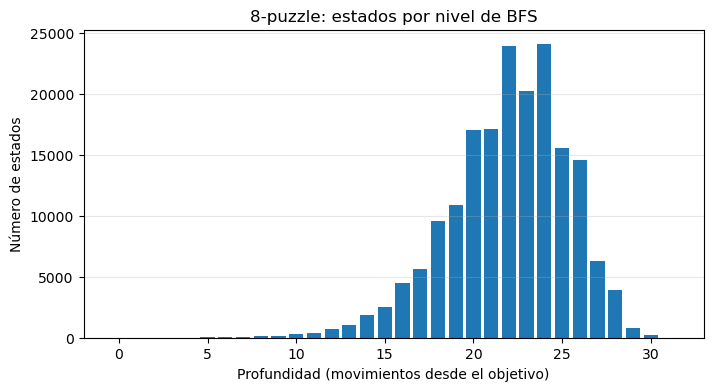

In [54]:
def tamanos_por_nivel(objetivo):
    visitados = {objetivo}
    nivel = [objetivo]
    tamanos = []
    while nivel:
        tamanos.append(len(nivel))
        siguiente = []
        for e in nivel:
            for n in sucesores_8_puzzle(e):
                if n not in visitados:
                    visitados.add(n)
                    siguiente.append(n)
        nivel = siguiente
    return tamanos

tamanos = tamanos_por_nivel(estado_objetivo)
acumulado = 0
print(f"{'Profundidad':>11} {'Estados en el nivel':>20} {'Acumulado':>10}")
for d, t in enumerate(tamanos):
    acumulado += t
    if d % 5 == 0 or d == len(tamanos) - 1:
        print(f"{d:11d} {t:20d} {acumulado:10d}")

plt.figure(figsize=(8, 4))
plt.bar(range(len(tamanos)), tamanos)
plt.xlabel("Profundidad (movimientos desde el objetivo)")
plt.ylabel("Número de estados")
plt.title("8-puzzle: estados por nivel de BFS")
plt.grid(axis="y", alpha=0.3)
plt.show()

**Respuesta a la pregunta de la sección 9.2 — ¿qué problema aparece cuando el estado inicial está muy lejos del objetivo?**

El número de estados que BFS debe generar y guardar (cola + visitados) crece rápidamente con la profundidad: unos 20 estados a profundidad 5, unos 17 000 a profundidad 20, y 54 802 acumulados hasta ese nivel. BFS explora en todas las direcciones sin ninguna guía, por lo que el **tiempo y sobre todo la memoria** se disparan. Con un estado a 31 movimientos (uno de los dos más lejanos) recorrió los 181 440 estados alcanzables, es decir, todo el espacio. En puzzles mayores (15-puzzle, del orden de 10¹³ estados) esto sería inviable.

**Observación:** el `estado_inicial` que propone el notebook tiene 1 inversión y el objetivo 0, así que tienen distinta paridad y **no es resoluble**. BFS agota los 181 440 estados alcanzables (9!/2) y no encuentra solución; es el peor caso posible. Por eso se prueba además con estados resolubles.

# 10. Conclusiones

En esta práctica observamos que:

- Un problema puede modelarse mediante **estados, acciones y una condición objetivo**.
- BFS y DFS son estrategias de búsqueda **no informada**.
- BFS explora por niveles y utiliza una cola.
- DFS profundiza por ramas y utiliza una pila.
- BFS puede encontrar caminos mínimos cuando todas las acciones tienen el mismo costo.
- DFS puede requerir menos memoria, pero no garantiza un camino mínimo.
- El tamaño del espacio de estados puede hacer que una búsqueda no informada sea muy costosa.

---

## Pregunta

Si el espacio de búsqueda contiene millones de estados:

> **¿Podríamos utilizar información del problema para decidir qué estados parecen más prometedores y explorarlos primero?**

Esa pregunta nos lleva a la **búsqueda informada y las heurísticas**.

# 11. Taller para estudiar

1. Modifique el orden de los movimientos del laberinto y compare el comportamiento de DFS.
2. Construya un laberinto de al menos `10 × 10` y compare BFS y DFS en:
   - longitud del camino,
   - estados explorados.
3. Modifique el problema de los recipientes para capacidades diferentes y determine si existe solución.
4. Complete la implementación BFS del 8-puzzle.
5. Explique, con sus propias palabras, por qué BFS y DFS se consideran algoritmos de búsqueda **no informada**.

### Uso de IA generativa

Si utiliza una herramienta de IA generativa en esta actividad, indique:

- herramienta utilizada,
- propósito de uso,
- partes de la solución en las que fue empleada.

Recuerde: usted debe estar en capacidad de **explicar y defender completamente** el código y las respuestas entregadas.

# 12. Solución del taller

## 12.1 Orden de `MOVIMIENTOS` en el laberinto y comportamiento de DFS

DFS apila los sucesores en el orden de `MOVIMIENTOS` y extrae el **último**, así que el último movimiento de la lista es el que se intenta primero. Se cambia temporalmente la variable global y se restaura al terminar.

In [55]:
import itertools
import statistics
from collections import Counter

ORDEN_ORIGINAL = list(MOVIMIENTOS)
SIMBOLO = {(1, 0): "↓", (-1, 0): "↑", (0, 1): "→", (0, -1): "←"}

def texto_orden(orden):
    return " ".join(SIMBOLO[m] for m in orden)

def dfs_con_orden(lab, inicio, objetivo, orden):
    """DFS con un orden de movimientos distinto (restaura el global al terminar)."""
    global MOVIMIENTOS
    MOVIMIENTOS = list(orden)
    try:
        return dfs_camino_laberinto(lab, inicio, objetivo)
    finally:
        MOVIMIENTOS = list(ORDEN_ORIGINAL)

ordenes_prueba = {
    "Original":         ORDEN_ORIGINAL,
    "Invertido":        ORDEN_ORIGINAL[::-1],
    "Derecha primero":  [(0, 1), (1, 0), (0, -1), (-1, 0)],
    "Arriba primero":   [(-1, 0), (0, -1), (1, 0), (0, 1)],
}

bfs_ref = bfs_camino_laberinto(laberinto, INICIO, OBJETIVO)
print(f"{'BFS (referencia)':18s} {'':9s} longitud = {len(bfs_ref['camino'])-1} | explorados = {bfs_ref['explorados']}")

for nombre, orden in ordenes_prueba.items():
    r = dfs_con_orden(laberinto, INICIO, OBJETIVO, orden)
    print(f"DFS {nombre:14s} {texto_orden(orden):9s} longitud = {len(r['camino'])-1} | explorados = {r['explorados']}")

BFS (referencia)             longitud = 8 | explorados = 16
DFS Original       ↓ ↑ → ←   longitud = 8 | explorados = 18
DFS Invertido      ← → ↑ ↓   longitud = 8 | explorados = 18
DFS Derecha primero → ↓ ← ↑   longitud = 8 | explorados = 18
DFS Arriba primero ↑ ← ↓ →   longitud = 8 | explorados = 12


Para no depender de cuatro órdenes elegidos a mano, se prueban las **24 permutaciones** posibles.

Longitudes de camino distintas: [8]
Explorados: mínimo = 11 | máximo = 18 | media = 15.7
Distribución (explorados: nº de órdenes): {11: 4, 12: 3, 13: 1, 17: 5, 18: 11}
Caminos distintos obtenidos: 2
Orden mejor: ↑ → ↓ ← -> explorados = 11
Orden peor: ↓ ↑ → ← -> explorados = 18


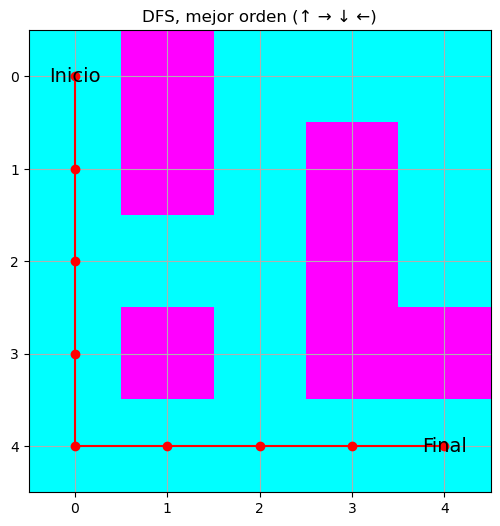

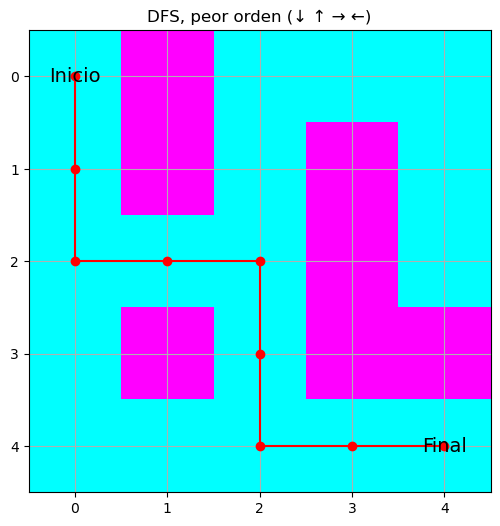

In [56]:
resumen = {}
for orden in itertools.permutations(ORDEN_ORIGINAL):
    r = dfs_con_orden(laberinto, INICIO, OBJETIVO, orden)
    resumen[orden] = (len(r["camino"]) - 1, r["explorados"], r["camino"])

longitudes = [v[0] for v in resumen.values()]
explorados = [v[1] for v in resumen.values()]
print("Longitudes de camino distintas:", sorted(set(longitudes)))
print("Explorados: mínimo =", min(explorados), "| máximo =", max(explorados),
      "| media =", round(statistics.mean(explorados), 1))
print("Distribución (explorados: nº de órdenes):", dict(sorted(Counter(explorados).items())))
print("Caminos distintos obtenidos:", len({tuple(v[2]) for v in resumen.values()}))

mejor = min(resumen, key=lambda o: resumen[o][1])
peor = max(resumen, key=lambda o: resumen[o][1])
for etiqueta, o in (("mejor", mejor), ("peor", peor)):
    print(f"Orden {etiqueta}: {texto_orden(o)} -> explorados = {resumen[o][1]}")

mostrar_laberinto(laberinto, resumen[mejor][2], INICIO, OBJETIVO, f"DFS, mejor orden ({texto_orden(mejor)})")
mostrar_laberinto(laberinto, resumen[peor][2], INICIO, OBJETIVO, f"DFS, peor orden ({texto_orden(peor)})")

**Interpretación (12.1):**

- La **longitud del camino no cambia** (siempre 8), pero los **estados explorados sí**: entre 11 y 18 según el orden (media 15,7) y aparecen 2 caminos distintos entre las 24 permutaciones.
- Con `↑ ← ↓ →` DFS explora 12 estados; con el orden original (`↓ ↑ → ←`), 18. El orden de generación de sucesores decide qué rama se recorre primero y, por tanto, cuántas ramas sin salida se visitan antes de llegar al objetivo.
- Conclusión: DFS es sensible al orden de los sucesores; BFS no (siempre explora por niveles).

## 12.2 Laberinto de 10 × 10: BFS vs. DFS

        longitud  explorados
BFS           18          84
DFS           26          84


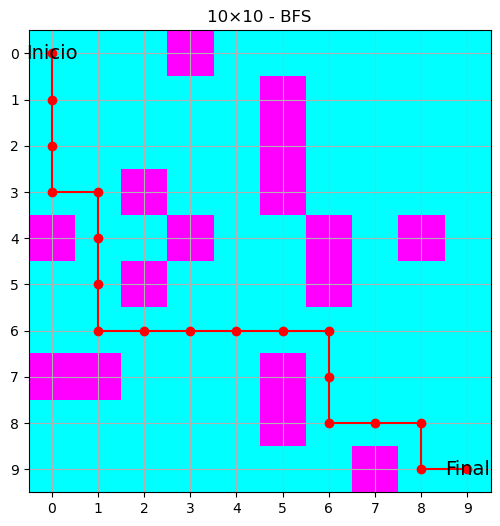

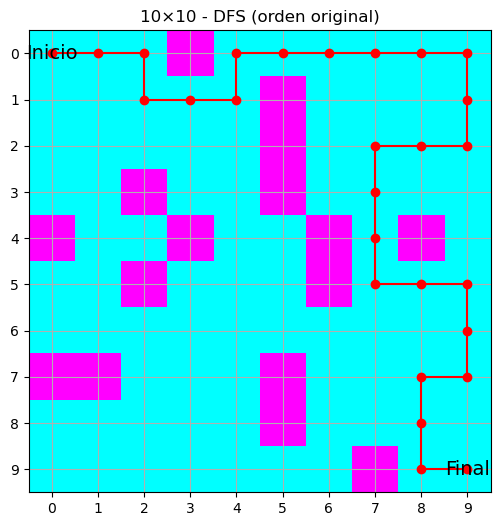

In [57]:
laberinto_10 = [
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 0, 0, 0],
    [1, 0, 0, 1, 0, 0, 1, 0, 1, 0],
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
]
INICIO_10, OBJETIVO_10 = (0, 0), (9, 9)

bfs_10 = bfs_camino_laberinto(laberinto_10, INICIO_10, OBJETIVO_10)
dfs_10 = dfs_camino_laberinto(laberinto_10, INICIO_10, OBJETIVO_10)   # orden original

print(f"{'':6s} {'longitud':>9s} {'explorados':>11s}")
print(f"{'BFS':6s} {len(bfs_10['camino'])-1:9d} {bfs_10['explorados']:11d}")
print(f"{'DFS':6s} {len(dfs_10['camino'])-1:9d} {dfs_10['explorados']:11d}")

mostrar_laberinto(laberinto_10, bfs_10["camino"], INICIO_10, OBJETIVO_10, "10×10 - BFS")
mostrar_laberinto(laberinto_10, dfs_10["camino"], INICIO_10, OBJETIVO_10, "10×10 - DFS (orden original)")

Como el resultado de DFS depende del orden, se repite con las 24 permutaciones.

In [58]:
res10 = []
for orden in itertools.permutations(ORDEN_ORIGINAL):
    r = dfs_con_orden(laberinto_10, INICIO_10, OBJETIVO_10, orden)
    res10.append((len(r["camino"]) - 1, r["explorados"]))

lon = [x[0] for x in res10]
exp = [x[1] for x in res10]
print(f"BFS            : longitud = {len(bfs_10['camino'])-1}, explorados = {bfs_10['explorados']}")
print(f"DFS (24 órdenes): longitud  min/media/max = {min(lon)}/{statistics.mean(lon):.1f}/{max(lon)}")
print(f"DFS (24 órdenes): explorados min/media/max = {min(exp)}/{statistics.mean(exp):.1f}/{max(exp)}")
print("Órdenes de DFS con camino óptimo:", sum(1 for l in lon if l == len(bfs_10['camino']) - 1), "de 24")

BFS            : longitud = 18, explorados = 84
DFS (24 órdenes): longitud  min/media/max = 18/27.3/40
DFS (24 órdenes): explorados min/media/max = 34/62.6/84
Órdenes de DFS con camino óptimo: 3 de 24


**Interpretación (12.2):**

- **Longitud:** BFS obtiene el camino óptimo (18 movimientos). DFS con el orden original obtiene 26 (44 % más largo); entre las 24 permutaciones va de 18 a 40 (media 27,3) y solo 3 de 24 órdenes dan el camino óptimo.
- **Estados explorados:** BFS descubre las 84 celdas libres antes de llegar a la esquina opuesta. DFS explora entre 34 y 84 (media 62,6): puede explorar menos, pero a cambio no garantiza un camino mínimo.
- En un laberinto mayor y con más rutas las diferencias se acentúan respecto al 5 × 5: BFS garantiza optimalidad, DFS depende del orden y de la suerte.

## 12.3 Recipientes de agua con otras capacidades

Se usa `bfs_recipientes` (devuelve `None` si no hay solución) y se contrasta con la condición teórica: se puede medir `objetivo` litros si `objetivo ≤ max(M, N)` y `objetivo` es múltiplo de `mcd(M, N)`.

In [59]:
from math import gcd

def hay_solucion_teorica(M, N, objetivo):
    return objetivo <= max(M, N) and objetivo % gcd(M, N) == 0

casos = [(5, 3, 4), (4, 2, 3), (7, 5, 3), (6, 4, 5), (9, 6, 3),
         (9, 6, 4), (8, 5, 4), (10, 4, 7), (7, 3, 5)]

print(f"{'M':>2} {'N':>2} {'obj':>3} {'mcd':>3} {'BFS':>10} {'pasos':>5}")
for M, N, obj in casos:
    sol = bfs_recipientes(M, N, obj)
    pasos = len(sol["acciones"]) if sol else "-"
    print(f"{M:2d} {N:2d} {obj:3d} {gcd(M, N):3d} {'Sí' if sol else 'No':>10} {pasos:>5}")

# Validación exhaustiva de la regla teórica contra BFS
total, coinciden = 0, 0
for M in range(1, 10):
    for N in range(1, 10):
        for obj in range(1, 10):
            total += 1
            coinciden += (bfs_recipientes(M, N, obj) is not None) == hay_solucion_teorica(M, N, obj)
print(f"\nRegla teórica vs BFS: coinciden {coinciden} de {total} casos (M, N, objetivo entre 1 y 9)")

print("\nEjemplo con la solución más larga de la tabla: M=8, N=5, objetivo=4")
mostrar_solucion_recipientes(bfs_recipientes(8, 5, 4))

 M  N obj mcd        BFS pasos
 5  3   4   1         Sí     6
 4  2   3   2         No     -
 7  5   3   1         Sí     4
 6  4   5   2         No     -
 9  6   3   3         Sí     2
 9  6   4   3         No     -
 8  5   4   1         Sí    10
10  4   7   2         No     -
 7  3   5   1         Sí     8

Regla teórica vs BFS: coinciden 729 de 729 casos (M, N, objetivo entre 1 y 9)

Ejemplo con la solución más larga de la tabla: M=8, N=5, objetivo=4
Estado inicial: (0, 0)
1. Llenar N        -> (0, 5)
2. Verter N → M    -> (5, 0)
3. Llenar N        -> (5, 5)
4. Verter N → M    -> (8, 2)
5. Vaciar M        -> (0, 2)
6. Verter N → M    -> (2, 0)
7. Llenar N        -> (2, 5)
8. Verter N → M    -> (7, 0)
9. Llenar N        -> (7, 5)
10. Verter N → M    -> (8, 4)

Estados explorados: 23


**Interpretación (12.3):**

- Hay solución cuando `objetivo ≤ max(M, N)` y `objetivo` es múltiplo de `mcd(M, N)`. La regla coincide con BFS en los 729 casos probados.
- **Sin solución:** `(4, 2, 3)`, `(6, 4, 5)`, `(9, 6, 4)` y `(10, 4, 7)`: en todos el objetivo no es múltiplo del `mcd`. Como toda cantidad que se puede medir es de la forma `a·M + b·N`, siempre es múltiplo del `mcd(M, N)`.
- **Con solución:** `(5, 3, 4)` en 6 pasos, `(7, 5, 3)` en 4, `(9, 6, 3)` en 2, `(8, 5, 4)` en 10 y `(7, 3, 5)` en 8.
- Cuando `mcd = 1` y el objetivo no supera al recipiente mayor, siempre hay solución.

## 12.4 BFS del 8-puzzle

Implementado en la sección 9.2 y probado en las secciones 9.3 y 9.4.

## 12.5 ¿Por qué BFS y DFS son búsquedas *no informadas*?

Porque solo usan la **estructura del problema**: qué estados son sucesores de otro y si un estado es el objetivo. No disponen de ninguna estimación de qué tan cerca está un estado de la meta (una heurística), así que no pueden distinguir un estado prometedor de uno que no lo es.

El orden de exploración lo fija únicamente la estructura de datos (cola FIFO en BFS, pila LIFO en DFS) y el orden en que se generan los sucesores, no el conocimiento del problema. Por eso pueden explorar muchos estados irrelevantes (en el 8-puzzle llegaron a recorrer los 181 440). La búsqueda informada (voraz, A*) usa una función heurística `h(n)` para explorar primero los estados más prometedores.

### Uso de IA generativa

* **Herramienta utilizada:** Claude (Anthropic), Gemini (Google).

* **Propósito de uso:** apoyo como herramienta complementaria durante el desarrollo del taller, principalmente para orientar la elaboración de la solución, revisar y validar las implementaciones, apoyar la ejecución e interpretación de pruebas y contribuir a la redacción y revisión de las respuestas de análisis.

* **Partes en las que se empleó:** apoyo en la implementación y pruebas de `bfs_8_puzzle` (secciones 9.2–9.4), en el apoyo e interpretación de los experimentos y respuestas de la sección 12 (laberintos, recipientes y preguntas conceptuales), y en la revisión y ajuste de las respuestas a las preguntas de análisis de las secciones 7 y 8.

* **Participación del estudiante:** las decisiones sobre la solución, adaptación del código, ejecución y verificación de las pruebas, interpretación de los resultados y elaboración final del trabajo fueron realizadas y revisadas por el estudiante, utilizando la IA como herramienta de apoyo.